Training XGBoost...


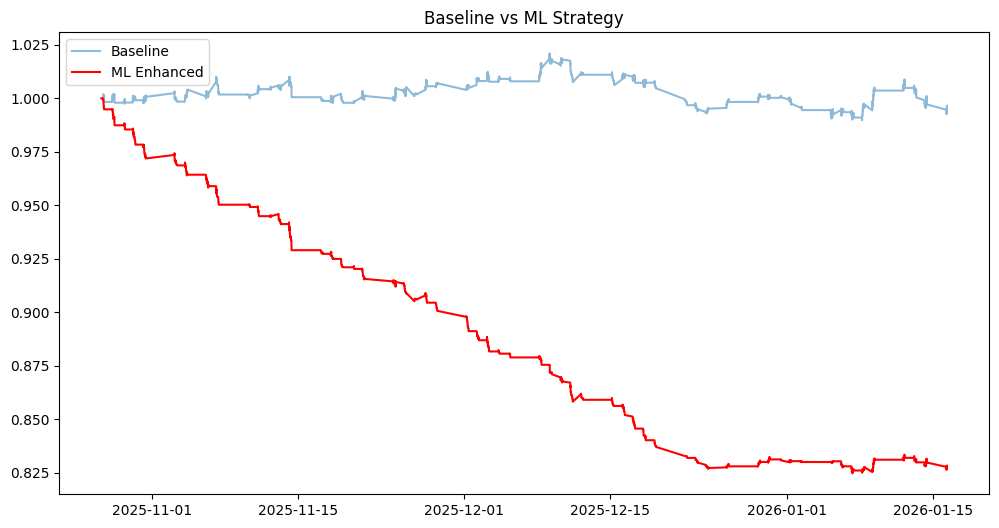

ML Results Saved.


In [1]:
# Cell 1: Imports
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- BRIDGE BLOCK ---
# This allows us to import from the 'src' folder
sys.path.append(os.path.abspath(os.path.join('..')))
from src.ml_models import get_xgb_gatekeeper
# --------------------

# Cell 2: Load Data
# Note: Ensure baseline_results.csv was generated by notebook 05
df = pd.read_csv("../results/baseline_results.csv", index_col=0, parse_dates=True)

# Rename 'Market_Ret' to 'Market_Returns' if needed to match previous steps
if 'Market_Ret' in df.columns and 'Market_Returns' not in df.columns:
    df.rename(columns={'Market_Ret': 'Market_Returns'}, inplace=True)

# Cell 3: Feature Engineering for ML
# Target: 1 if the NEXT candle is positive, else 0
df['Target'] = (df['Market_Returns'].shift(-1) > 0).astype(int)

# Select features (Ensure these exist in your CSV)
features = ['Delta_CE', 'Delta_PE', 'Gamma', 'Vega', 'PCR_OI', 'Regime', 'Avg_IV']
# Fill NaNs with 0 to prevent XGBoost errors
X = df[features].fillna(0)
y = df['Target']

# Cell 4: Train/Test Split
split = int(len(df) * 0.7)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Cell 5: Train Model
print("Training XGBoost...")
model = get_xgb_gatekeeper()
model.fit(X_train, y_train)

# Cell 6: Backtest with ML Filter
# Predict probabilities
df['ML_Prob'] = model.predict_proba(X)[:, 1]

# Logic: Only take the baseline signal if ML Confidence > 50%
df['ML_Signal'] = np.where((df['Signal'] != 0) & (df['ML_Prob'] > 0.5), df['Signal'], 0)
df['ML_Strategy_Returns'] = df['ML_Signal'].shift(1) * df['Market_Returns']

# Cell 7: Plot Results
plt.figure(figsize=(12, 6))
plt.plot((1 + df['Strategy_Ret'].fillna(0)).cumprod(), label='Baseline', alpha=0.5)
plt.plot((1 + df['ML_Strategy_Returns'].fillna(0)).cumprod(), label='ML Enhanced', color='red')
plt.title("Baseline vs ML Strategy")
plt.savefig("../plots/feature_importance02.png")
plt.legend()
plt.show()

# Cell 8: Save
df.to_csv("../results/ml_results.csv")
print("ML Results Saved.")


In [2]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
from src.ml_models import get_xgb_gatekeeper

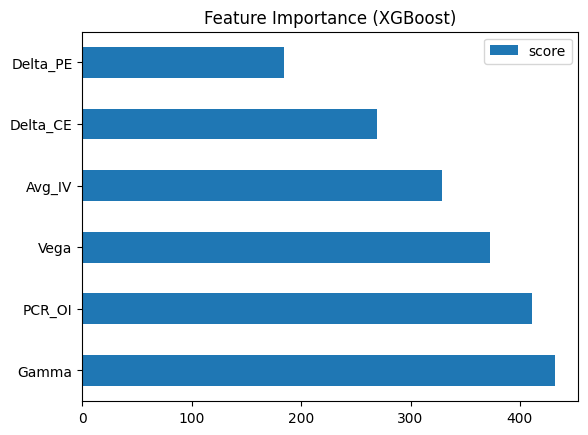

In [3]:
import matplotlib.pyplot as plt

# Plot feature importance
feature_important = model.get_booster().get_score(importance_type='weight')
keys = list(feature_important.keys())
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.plot(kind='barh', title='Feature Importance (XGBoost)')
plt.savefig("../plots/feature_importance03.png")
plt.show()

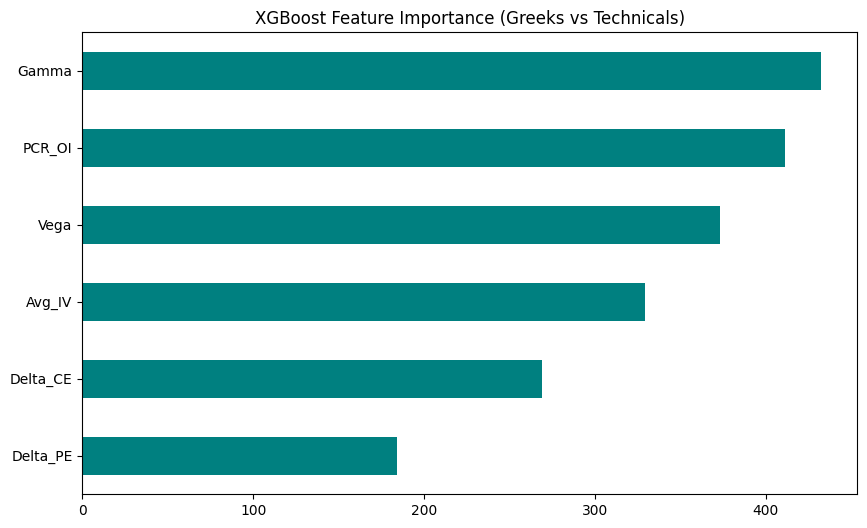

In [4]:
import matplotlib.pyplot as plt

# Get feature importance from XGBoost
importance = model.get_booster().get_score(importance_type='weight')
# Sort and plot
plt.figure(figsize=(10,6))
pd.Series(importance).sort_values().plot(kind='barh', color='teal')
plt.title("XGBoost Feature Importance (Greeks vs Technicals)")
plt.savefig("../plots/feature_importance04.png")
plt.show()